In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [19]:
df = pd.read_csv("Superstore.csv", encoding="latin1")

In [20]:
df.columns = df.columns.str.strip()

print("Dataset Loaded Successfully\n")

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Loaded Successfully

Shape:
(9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [21]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

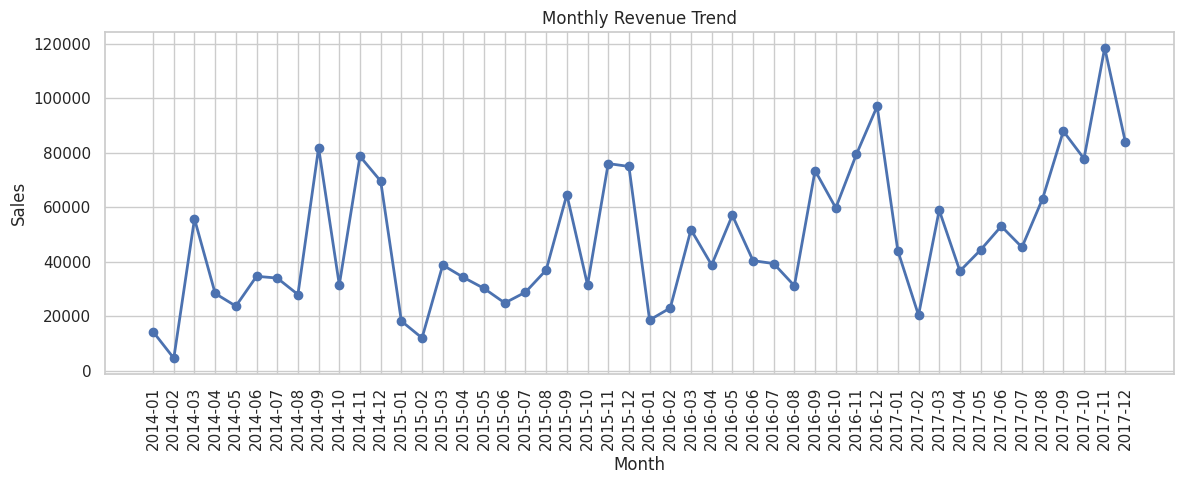

In [22]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.grid(True)

plt.tight_layout()

plt.savefig("Monthly_Revenue_Trend.png")

plt.show()

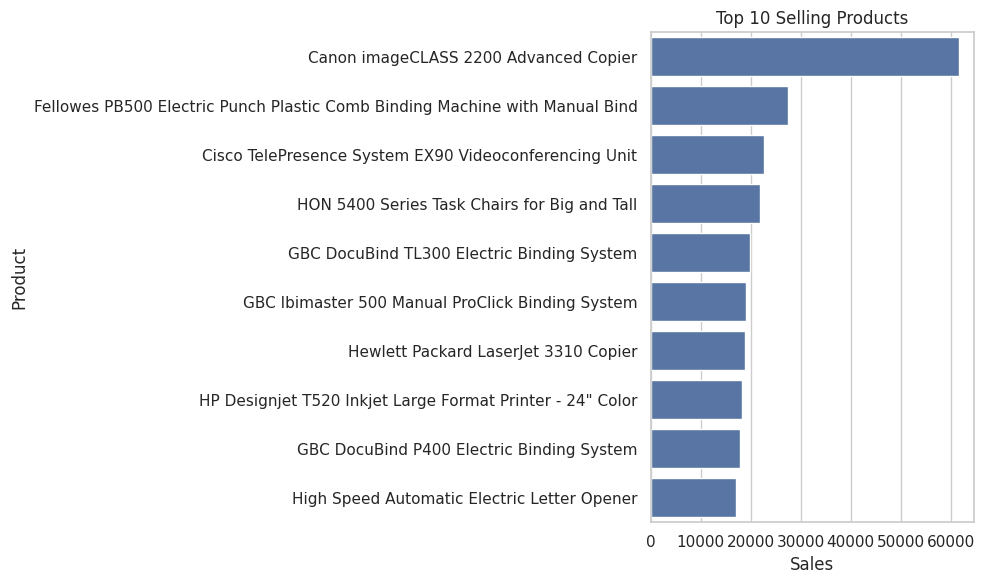

In [23]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Selling Products")

plt.xlabel("Sales")

plt.ylabel("Product")

plt.tight_layout()

plt.savefig("Top10_Selling_Products.png")

plt.show()

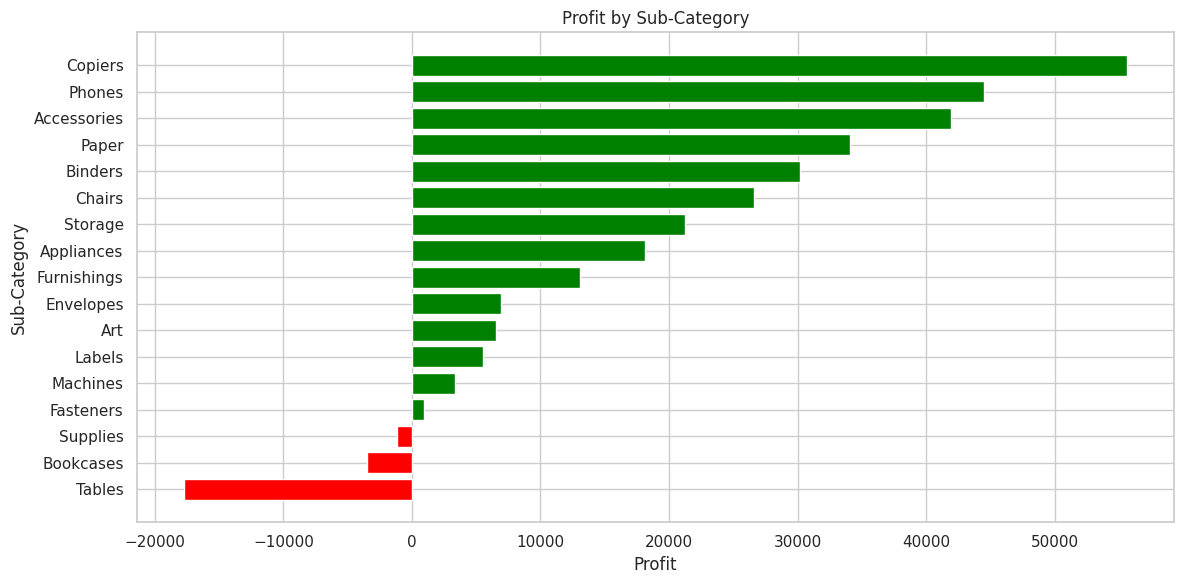

In [24]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)

colors = []

for value in subcategory_profit.values:
    if value >= 0:
        colors.append("green")
    else:
        colors.append("red")

plt.figure(figsize=(12,6))

plt.barh(
    subcategory_profit.index,
    subcategory_profit.values,
    color=colors
)

plt.title("Profit by Sub-Category")

plt.xlabel("Profit")

plt.ylabel("Sub-Category")

plt.tight_layout()

plt.savefig("Profit_by_SubCategory.png")

plt.show()

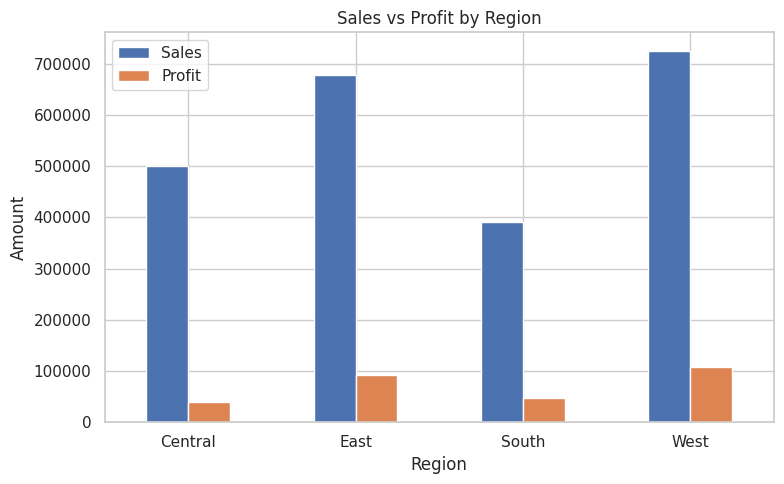

In [25]:
region_summary = (
    df.groupby("Region")[["Sales","Profit"]]
    .sum()
)

region_summary.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales vs Profit by Region")

plt.xlabel("Region")

plt.ylabel("Amount")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("Sales_vs_Profit_by_Region.png")

plt.show()

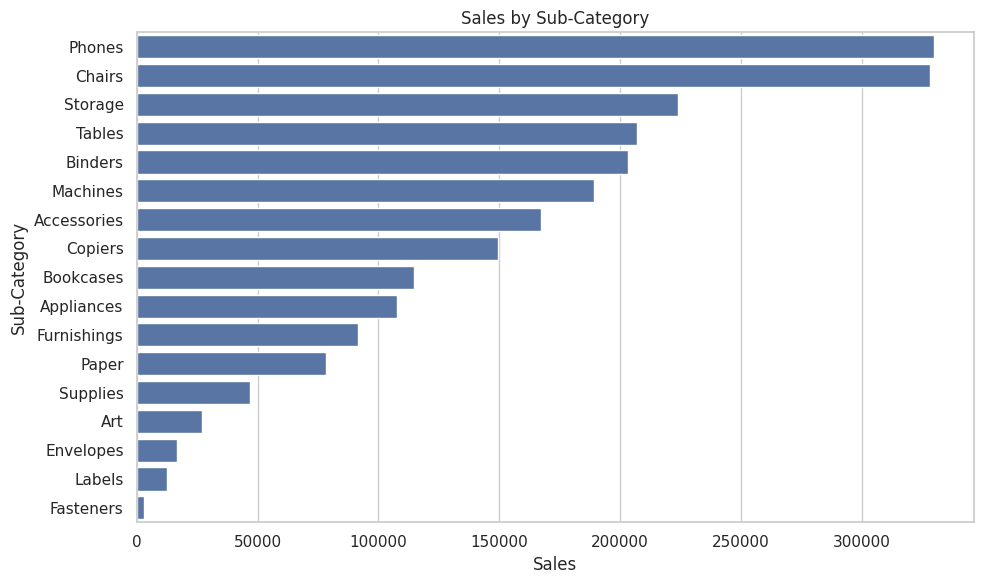

In [26]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=subcategory_sales.values,
    y=subcategory_sales.index
)

plt.title("Sales by Sub-Category")

plt.xlabel("Sales")

plt.ylabel("Sub-Category")

plt.tight_layout()

plt.savefig("Sales_by_SubCategory.png")

plt.show()

In [10]:
print("\nSummary Statistics")
print(df.describe(include="all"))

print("\nMovies vs TV Shows")
print(df["type"].value_counts())

print("\nTop 10 Genres")
print(top_genres)

print("\nTop 10 Countries")
print(top_country)


Summary Statistics
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  Rajiv Chilaka  David Attenborough   
freq         1   6131       1             19                  19   
mean       NaN    NaN     NaN            NaN                 NaN   
min        NaN    NaN     NaN            NaN                 NaN   
25%        NaN    NaN     NaN            NaN                 NaN   
50%        NaN    NaN     NaN            NaN                 NaN   
75%        NaN    NaN     NaN            NaN                 NaN   
max        NaN    NaN     NaN            NaN                 NaN   
std        NaN    NaN     NaN            NaN                 NaN   

              country                     date_added  release_year rating  \
count            7976                           8797   8807.000000   8803   
unique   